# Hybrid Imputation Showcase

This notebook documents a portfolio-style hybrid imputation system for real-estate listings. Instead of using one blunt imputer, the pipeline combines:

- direct regex extraction from listing text
- a structured regression model
- a text-based NLP model
- provenance and confidence tracking for every imputed field

It also distinguishes between two output modes:

- `analysis_safe`: may use `list_price` as an input feature for imputing house attributes
- `price_model_safe`: does not use `list_price`, which avoids leakage when building downstream price models

In [1]:
import os
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

mpl_config_dir = PROJECT_ROOT / '.matplotlib'
mpl_config_dir.mkdir(exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(mpl_config_dir)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
ANALYSIS_PATH = DATA_DIR / 'real_estate_hybrid_imputed_analysis.parquet'
PRICE_SAFE_PATH = DATA_DIR / 'real_estate_hybrid_imputed_price_safe.parquet'
REPORT_PATH = DATA_DIR / 'real_estate_hybrid_imputation_report.json'

analysis_df = pd.read_parquet(ANALYSIS_PATH)
price_safe_df = pd.read_parquet(PRICE_SAFE_PATH)
report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))

analysis_df.shape, price_safe_df.shape

((75276, 87), (75276, 87))

## What gets imputed

In [2]:
TARGETS = ['beds', 'baths', 'sqft', 'garage', 'stories', 'year_built']
pd.DataFrame(report['analysis_safe']['targets']).T

,missing_before,regex_imputed,hybrid_model_imputed,missing_after
beds,13365,368,12997,0
baths,12794,429,12365,0
sqft,14674,756,13918,0
garage,30267,260,30007,0
stories,29665,1031,28634,0
year_built,34453,866,33587,0


## Imputation strategy by field

Regex extraction only works when the listing text explicitly states the value. For example, some descriptions mention `3 bedrooms`, `2.5 baths`, `2-car garage`, `2,100 sq ft`, or `built in 1998`. Everything else falls through to the hybrid prediction stage.

In [3]:
summary_rows = []
for target in TARGETS:
    summary_rows.append({
        'target': target,
        'imputed_rows': int(analysis_df[f'{target}_was_imputed'].sum()),
        'regex_rows': int((analysis_df[f'{target}_imputation_source'] == 'regex').sum()),
        'hybrid_rows': int((analysis_df[f'{target}_imputation_source'] == 'hybrid_model').sum()),
        'avg_confidence': round(analysis_df.loc[analysis_df[f'{target}_was_imputed'], f'{target}_imputation_confidence'].mean(), 3),
    })

imputation_mix = pd.DataFrame(summary_rows)
imputation_mix

,target,imputed_rows,regex_rows,hybrid_rows,avg_confidence
0,beds,13365,368,12997,0.784
1,baths,12794,429,12365,0.787
2,sqft,14674,756,13918,0.194
3,garage,30267,260,30007,0.715
4,stories,29665,1031,28634,0.793
5,year_built,34453,866,33587,0.486


C:\Users\rjpet\AppData\Local\Temp\ipykernel_13396\1194127958.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imputation_mix, x='avg_confidence', y='target', palette='viridis', ax=axes[1])


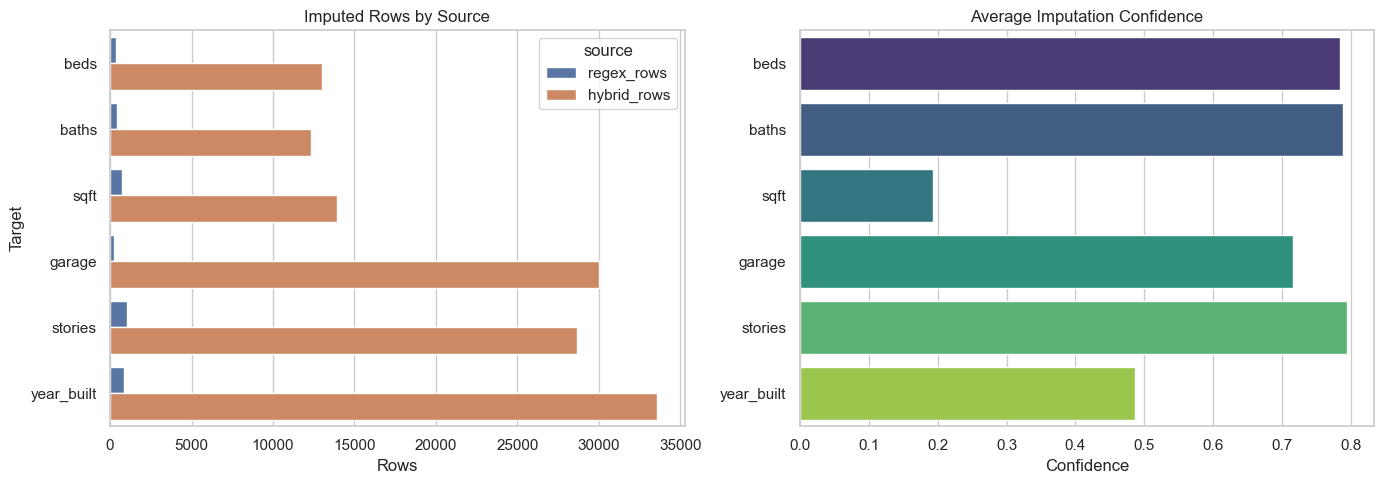

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = imputation_mix.melt(
    id_vars='target',
    value_vars=['regex_rows', 'hybrid_rows'],
    var_name='source',
    value_name='rows',
)
sns.barplot(data=plot_df, x='rows', y='target', hue='source', ax=axes[0])
axes[0].set_title('Imputed Rows by Source')
axes[0].set_xlabel('Rows')
axes[0].set_ylabel('Target')

sns.barplot(data=imputation_mix, x='avg_confidence', y='target', palette='viridis', ax=axes[1])
axes[1].set_title('Average Imputation Confidence')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Provenance columns in the output table

Each imputed target produces a small audit trail. For example, `beds` adds:

- `beds_was_imputed`
- `beds_imputation_source`
- `beds_imputation_confidence`
- `beds_regex_candidate`
- `beds_structured_prediction`
- `beds_text_prediction`

That makes the imputation output explainable rather than opaque.

In [5]:
cols = [
    'state',
    'text',
    'beds',
    'beds_imputation_source',
    'beds_imputation_confidence',
    'beds_regex_candidate',
    'beds_structured_prediction',
    'beds_text_prediction',
]
analysis_df.loc[analysis_df['beds_was_imputed'], cols].head(10)

,state,text,beds,beds_imputation_source,beds_imputation_confidence,beds_regex_candidate,beds_structured_prediction,beds_text_prediction
16,Colorado,"Privacy, convenience and VIEWS from this tranquil 35 acre parcel located about a third of the way up Red Mountain Ranch. This is the true Colorado Rocky Mou...",3.0,hybrid_model,0.78,NaN,3.0,2.0
169,Colorado,"Rare find and incredible opportunity to own this 40-acre secluded lot with ""Must-See"" panoramic views of Colorado's breathtaking Mountain ranges. This prope...",3.0,hybrid_model,0.80,NaN,3.0,3.0
170,Colorado,"Tucked away at the end of a peaceful cul-de-sac, this 2.5-acre retreat delivers wide-open mountain views, true privacy, and endless possibilities. The charm...",1.0,hybrid_model,0.78,NaN,1.0,2.0
181,Colorado,ATTENTION: BUYER MAY APPLY FOR WATER RIGHTS OFF THE SAMBRITO CREEK!!!! This charming and conveniently accessible four-acre property presents an ideal locati...,3.0,hybrid_model,0.78,NaN,3.0,4.0
185,Colorado,"This 35-acre property offers stunning mountain views and a prime location with quick access to schools, shopping, and other amenities. The Ag 35 zoning perm...",3.0,hybrid_model,0.80,NaN,3.0,3.0
186,Colorado,"Prime Summer Escape Near Pike National Forest! This beautiful 2-acre lot in the coveted Indian Mountain community offers the perfect mix of privacy, natural...",1.0,hybrid_model,0.74,NaN,0.0,3.0
192,Colorado,On the corner of two county-maintained roads. 35 acres with excellent mountain views. No HOA. Purchaser can apply for domestic use well permit which allows ...,3.0,hybrid_model,0.80,NaN,3.0,3.0
195,Colorado,"Tucked away at the edge of Oehlmann Park, this exceptional 2.2-acre mountain lot in Conifer offers the rare opportunity to create a private retreat surround...",1.0,hybrid_model,0.74,NaN,0.0,3.0
225,Colorado,"AMAZING PRICE REDUCTION BY 50% AND LAST OPPORTUNITY TO OWN THIS SPRAWLING 22 ACRE SHOWCASE PARCEL: A GEOLOGIST DREAM WITH EXPOSED MINERALS. Come, and Own th...",1.0,hybrid_model,0.74,NaN,0.0,3.0
235,Colorado,"Nearly 8 acres of beautifully treed land with sweeping mountain views create the perfect blend of scenery and seclusion. Bordered by three roads, this parce...",2.0,hybrid_model,0.78,NaN,2.0,3.0


## Analysis-safe vs price-model-safe outputs

A key modeling nuance is leakage. If you use `list_price` to impute house attributes, then use those imputed attributes to predict `list_price`, you accidentally leak target information back into the feature space.

That is why the project writes two separate imputed tables. The next comparison shows that they are not identical.

In [6]:
difference_rows = []
for target in TARGETS:
    diff = (analysis_df[target] - price_safe_df[target]).abs()
    difference_rows.append({
        'target': target,
        'different_rows': int((diff.fillna(0) > 1e-9).sum()),
        'avg_abs_diff': round(diff.dropna().mean(), 3) if diff.notna().any() else 0,
    })

difference_df = pd.DataFrame(difference_rows)
difference_df

,target,different_rows,avg_abs_diff
0,beds,2881,0.039
1,baths,245,0.002
2,sqft,11921,331.020
3,garage,7895,0.156
4,stories,3569,0.030
5,year_built,30791,2.906


C:\Users\rjpet\AppData\Local\Temp\ipykernel_13396\3918820983.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=difference_df, x='different_rows', y='target', palette='magma', ax=ax)


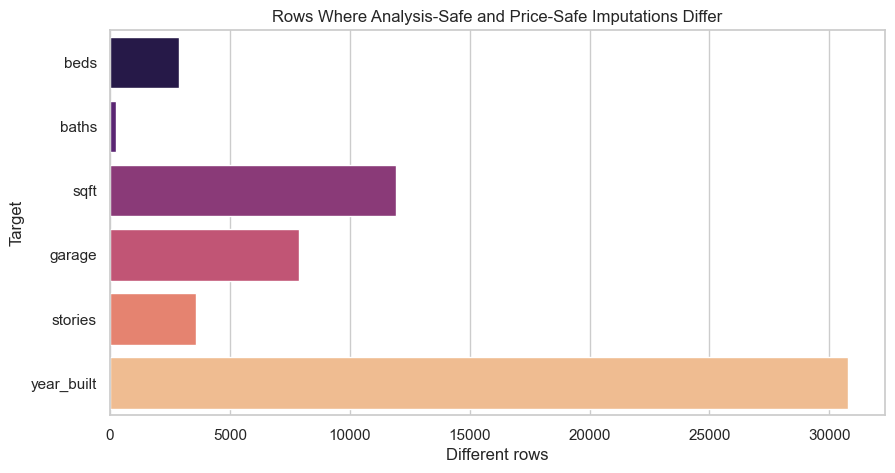

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=difference_df, x='different_rows', y='target', palette='magma', ax=ax)
ax.set_title('Rows Where Analysis-Safe and Price-Safe Imputations Differ')
ax.set_xlabel('Different rows')
ax.set_ylabel('Target')
plt.show()

## Why the hybrid design is interesting

This is more nuanced than a standard missing-value workflow.

What makes it portfolio-worthy:
- it uses direct extraction when the text contains explicit evidence
- it falls back to a structured regressor for the tabular side of the problem
- it also uses an NLP model so the language itself contributes to the imputation
- it records provenance and confidence for each filled value
- it explicitly separates leakage-safe and analysis-safe outputs

## Caveats and next refinements

This first hybrid version is already useful, but there are several ways to make it stronger:

- expand regex extraction for patterns like `4BR/3BA` or `2,448 square foot`
- calibrate confidence more formally using validation error
- add rule-based sanity checks between related fields like `beds`, `baths`, and `stories`
- evaluate the imputer by hiding known values and measuring recovery quality
- compare text-only, structured-only, and hybrid predictions side by side

## Recommended next step

Use the hybrid-imputed, price-safe table for the next modeling stages:

1. topic modeling or clustering on `text_clean`
2. semantic search / similar-listing retrieval
3. price prediction from text vs text + structured features

That gives the project a clean narrative: EDA, hybrid data repair, NLP discovery, search, and predictive modeling.